# 0.4. Предварительная временная эволюция Fourier-разностей фаз CO₂

Мои результаты · 04.10.2026.

**Текущий шаг: 0.4. Приоритет — temporal phase evolution, не phase vs frequency.**

[Принятый маршрут](PLAN.md#preparation) · [Входные данные и методика](details/02_data_checks.md#preliminary-fourier-phases) · [Предыдущий результат: амплитудные спектры](00_preliminary_co2_spectra.ipynb).

## 1. Цель, выбранная вертикаль и рабочая частота

Показываю три разности спектральных фаз во времени для LEO West, $(x,y)=(1,4)$: воздух → 5 см, 5 → 20 см, 20 → 50 см.
Воздух: LI-COR **1275**, подземные GMM222: **996 / 1012 / 1035**. Координаты воздуха по Excel $(0,4,0.25)$ м; он находится в 1 м по горизонтали от вертикали.

Обозначаю концентрацию CO₂ на уровне $j$ через $x_j(t)$:

$$x_j(t)=\text{концентрация CO}_2\text{ на уровне }j,$$

$$j=0,1,2,3\quad\leftrightarrow\quad\mathrm{air},\,5\,\mathrm{cm},\,20\,\mathrm{cm},\,50\,\mathrm{cm}.$$

$$x_0=C_{\rm air},\qquad x_1=C_5,\qquad x_2=C_{20},\qquad x_3=C_{50}.$$

**Амплитудные спектры показывают и другие пики, но сейчас они не исследуются. Для срочной предварительной демонстрации I.G. я принимаю рабочую частоту $f_0=1$ цикл/сутки ($T_0=24$ ч).**

Соответствующая угловая частота:

$$\omega_0=2\pi f_0=2\pi\ \text{рад/сутки}.$$

Здесь $f$ измеряется в циклах/сутки, а $\omega=2\pi f$ — соответствующая угловая частота в радианах/сутки.

Начальная длина окна — 30 суток, шаг — 1 сутки. Это изменяемые параметры демонстрации, не установленные физические масштабы.
Использую доступные одновременные записи четырёх каналов за 29.04.2025–01.10.2026. Кандидатный календарь: **[29.04.2025, 02.10.2026)**, 521 сутки. Исходные единицы сохранены: воздух `umol/mol`, подземные каналы `ppm`.

## 2. Общая двухчасовая сетка

Календарная двухчасовая ячейка имеет вид $B_k=[s_k,s_k+2\,\mathrm{ч})$. Множество $R_{jk}$ содержит все наблюдения канала $j$ в двухчасовой ячейке $B_k$, которые не были исключены на этапе технической проверки данных. [Правила технической проверки](details/02_data_checks.md).

Обозначаю через $n_{jk}$ число этих наблюдений, а через $x_{jk}$ — их среднюю концентрацию; $C_{jr}$ — значение отдельного наблюдения $r$ канала $j$:

$$n_{jk}=|R_{jk}|,\qquad x_{jk}=\frac{1}{n_{jk}}\sum_{r\in R_{jk}}C_{jr}.$$

Флаг проверки ячейки определяю так:

$$q_{jk}=\begin{cases}
1,&\text{если в ячейке есть хотя бы одно сохранённое наблюдение с флагом проверки},\\
0,&\text{иначе}.
\end{cases}$$

При $n_{jk}=0$ концентрация отсутствует. Счётчик 0 означает отсутствие наблюдений, а не нулевую концентрацию. Число наблюдений и флаг проверки каждой ячейки сохраняются вместе со средним.

В окне $W=[a,a+w)$ использую только **общие** ячейки:

$$I_W=\{k:B_k\subset W,\quad n_{jk}>0\ \text{для всех четырёх }j\},\qquad N=|I_W|.$$

Центры $s_k+1$ ч измерены в сутках от **одного общего начала** $t_{\mathrm{ref}}=$ 29.04.2025 00:00:00. Все четыре коэффициента используют один и тот же $I_W$. Календарь после удаления пропусков не сжимается. Интерполяции, нулевого заполнения концентраций и forward fill нет.

Двухчасовые средние $x_{jk}$ один раз вычисляются на общей календарной сетке 00:00, 02:00, … . Поскольку границы окон и их шаг задаются целым числом суток, они всегда совпадают с границами этой сетки и не разрезают двухчасовые ячейки. Поэтому предварительное вычисление $x_{jk}$ для всего календаря эквивалентно их отдельному вычислению внутри каждого окна. При изменении длины окна или шага интерактивный HTML использует эти же двухчасовые значения, заново определяет общие ячейки $I_W$, вычисляет оконные средние $\bar x_{j,W}$ и затем Fourier-коэффициенты $F_j(\omega_0;W)$.

Временные метки базы использую в исходном виде; их временная привязка подтверждена, дополнительного преобразования времени не выполняю.

## 3. Fourier-формулы, знак и ветвь

Здесь $x_j(t)$ — концентрация CO₂ на уровне $j$; $j=0,1,2,3$ соответствует воздуху, 5, 20 и 50 см. Среднее в ячейке $k$ обозначено $x_{jk}$. Использую угловую частоту $\omega_0=2\pi f_0=2\pi$ рад/сутки, где $f_0=1$ цикл/сутки, а $t_k$ измерено в сутках от общего начала времени.

В каждом окне удаляю среднее **по общим ячейкам**, с равным весом каждой ячейки, независимо от числа исходных наблюдений в ней:

$$\bar{x}_{j,W}=\frac1N\sum_{k\in I_W}x_{jk},\qquad x'_{jk}=x_{jk}-\bar{x}_{j,W},$$

$$F_j(\omega_0;W)=\frac1N\sum_{k\in I_W}\left(x_{jk}-\bar{x}_{j,W}\right)e^{-i\omega_0t_k}.$$

Это **direct complex Fourier coefficient** на фактически наблюдавшихся общих центрах ячеек. Нормировка $1/N$ фиксирована. Это не GLS; на неполной сетке расчёт не называется обычным FFT. Тренд и оконная весовая функция не добавлены.

$$\Delta\phi_{u\to v}=\mathrm{wrap}\!\left[\mathrm{Arg}\left(F_u\overline{F_v}\right)\right],\qquad
\mathrm{wrap}(\phi)=(\phi+\pi)\bmod(2\pi)-\pi.$$

Радианы лежат в $[-\pi,\pi)$; градусы $\Delta\phi\,180/\pi$ — в $[-180^\circ,180^\circ)$.

На полной регулярной сетке для $u(t)=\cos(\omega_0t)$, $v(t)=\cos(\omega_0(t-\tau))$ коэффициенты пропорциональны $1$ и $e^{-i\omega_0\tau}$, поэтому $\Delta\phi_{u\to v}=\mathrm{wrap}(\omega_0\tau)$. **Положительный знак соответствует запаздыванию второго сигнала для идеальной задержанной синусоиды**, с неоднозначностью по целому периоду. Это соглашение проверено синтетически ниже; физическое время переноса газа из него не выводится.

## 4. Математические формулы и соответствие Python

Точные выражения ниже взяты из [рабочего модуля](../sensorDB/preliminary_fourier_phases.py). `np` — `numpy`, `pd` — `pandas`. Четыре столбца `x` следуют порядку 1275 / 996 / 1012 / 1035.

| Операция | Формула | Python implementation | Library method / результат |
|---|---|---|---|
| Начало 2-часовой ячейки | $s_k=2\mathrm{ч}\,\lfloor t/(2\mathrm{ч})\rfloor$ | `retained.localdatetime.dt.floor('2h')` | `pandas.Series.dt.floor`: календарные начала ячеек |
| Среднее, число наблюдений, флаги | $x_{jk}=\sum C/n$; $n_{jk}$; логическое «или» | `retained.groupby('bin_start').agg(mean=('datavalue', 'mean'), n=('datavalue', 'size'), doubtful=('doubtful', 'any'), plateau_review=('plateau_review', 'any'), review=('review', 'any'), review_n=('review', 'sum'))` | `pandas.DataFrame.groupby`, `DataFrameGroupBy.agg`: mean / size / any / sum в каждой группе |
| Полный календарь | $s_k=t_{ref}+2k\mathrm{ч}$ | `pd.date_range(start, end, freq='2h', inclusive='left')`; `grouped['mean'].reindex(index)` | `pandas.date_range`, `pandas.Series.reindex`: все ячейки, отсутствующие средние — NaN |
| Центры и время в сутках | $t_k=(s_k+1\mathrm{ч}-t_{ref})/(24\mathrm{ч})$ | `grid.index + pd.Timedelta(hours=1)`; `(grid['bin_center'] - start).dt.total_seconds() / 86400` | `pandas.Timedelta`, `pandas.Series.dt.total_seconds`: длительность, секунды и затем сутки |
| Общие ячейки | $n_{jk}>0$ для всех $j$ | `grid[[f'mean_{s}' for s in IDS]].notna().all(axis=1)`; `window.loc[common]` | `pandas.DataFrame.notna`, `DataFrame.all`, `DataFrame.loc`: маска и общая подтаблица |
| Среднее по окну | $x'_{jk}=x_{jk}-\bar{x}_{j,W}$ | `centered = x - np.mean(x, axis=0)` | `numpy.mean`: четыре арифметических средних по общим ячейкам |
| Fourier exponent | $e_k=e^{-i\omega_0t_k}$ | `exponential = np.exp(-2j * np.pi * f0 * t_days)` | `numpy.exp`: комплексные экспоненты; `numpy.pi`: константа π |
| Fourier coefficient | $F_j=N^{-1}\sum x'_{jk}e_k$ | `np.sum(centered * exponential[:, None], axis=0) / len(t_days)` | `numpy.sum`: четыре комплексные суммы; встроенный `len`: N |
| Сопряжение и аргумент | $\mathrm{Arg}(F_u\overline F_v)$ | `np.angle(f_upper * np.conj(f_lower))` | `numpy.conj`: сопряжённое число; `numpy.angle`: аргумент в радианах |
| Ветвь | $(\phi+\pi)\bmod(2\pi)-\pi$ | `(phi + np.pi) % (2 * np.pi) - np.pi` | оператор `%` и `numpy.pi`; возвращает $[-\pi,\pi)$ |
| Градусы и модуль | $\Delta\phi\,180/\pi$; $\lvert F_j\rvert$ | `angle * 180 / np.pi`; `abs(coefficients[j])` | арифметика; встроенный `abs`: модуль комплексного числа |
| Покрытие и сомнительные ячейки | $N/M$; $\sum_{k\in I_W}q_k$ | `n/len(window)`; `int(used.any_review.sum())` | `len`, `pandas.Series.sum`, `int`: доля и число ячеек |
| Максимальный пробел | $2\mathrm{ч}\times\max$(длины серий отсутствующих ячеек) | `2*longest_missing_run(common)` | собственная функция; цикл и встроенный `max`, включая края окна |
| Календарь окон | $a_m=t_{ref}+m\,s$; центр $a_m+w/2$ | `range(0, total_bins - width + 1, step)`; `start+(end-start)/2` | встроенный `range`; арифметика `pandas.Timestamp` / `Timedelta` |
| Проверка определённости | $N\ge2$; $F_u\ne0$, $F_v\ne0$ | `len(t_days) < 2`; `abs(f_upper) == 0 or abs(f_lower) == 0`; `np.isfinite(...)` | `len`, `abs`, `numpy.isfinite`: вычислительная проверка, не научный допуск |

Выражение `np.exp(-2j * np.pi * f0 * t_days)` точно реализует $e^{-i\omega_0t}$ при $\omega_0=2\pi f_0$; численный алгоритм не изменён.

В коде `technically_retained=True` обозначает сохранение наблюдения после технической проверки. Флаг `review` объединяет `doubtful` и `plateau_review`; поле `review_n` содержит число сохранённых наблюдений с объединённым флагом в ячейке. В математическом обозначении $q_{jk}$ равен 1, если это число положительно. Для общей ячейки $q_k=\max_{j=0,1,2,3}q_{jk}$.

Один столбец CSV содержит одну конкретную величину; модули, действительные и мнимые части всех четырёх коэффициентов сохранены для независимой проверки. Двухчасовые средние, числа наблюдений и флаги сохранены отдельно.

## 5. Покрытие и вычислительная определённость

Для каждого окна сохраняю возможное число ячеек $M=12w$, фактическое $N$, $N/M$, самый длинный ряд отсутствующих общих ячеек **с учётом краёв**, число использованных ячеек с флагами и число таких ячеек во всём окне.

Новый численный порог покрытия или амплитуды **не введён**. Если $N<2$, после центрирования ненулевой коэффициент не определяется; статус — `INSUFFICIENT DATA`. При нулевом коэффициенте соответствующая парная фаза отсутствует; остальные вычислимые пары сохраняются. Очень малый ненулевой коэффициент может дать неустойчивую фазу: модули показаны, но порог их научной пригодности не установлен.

Все 7589 сохранённых измерений воздуха отмечены флагом незавершённой технической проверки LI-COR; сомнительные подземные наблюдения также сохранены. Возможность вычисления не означает научный допуск.

In [1]:
from pathlib import Path
import sys
import json
import pandas as pd
from IPython.display import display, Markdown
from PIL import Image

ROOT = next(p for p in (Path.cwd(), *Path.cwd().parents)
            if (p / 'Project_description/sensorDB/preliminary_fourier_phases.py').exists())
sys.path.insert(0, str(ROOT / 'Project_description/sensorDB'))
import preliminary_fourier_phases as phases

window_days, step_days = 30, 1
grid, phase_table, coverage, validation = phases.generate(
    window_days=window_days, step_days=step_days)
OUT = phases.OUT

def show_image(name, width=1400):
    with Image.open(OUT / name) as image:
        image = image.copy()
        image.thumbnail((width, 1200))
        display(image)

summary = pd.DataFrame([
    ('Кандидатный календарь', '[29.04.2025, 02.10.2026)'),
    ('Общие ячейки во всём календаре', f"{validation['common_bins']} из {validation['possible_calendar_bins']}"),
    ('Окон / вычислены все три фазы', f"{len(phase_table)} / {validation['all_three_phases_computable']}"),
    ('Окон с флагами / неопределённых', f"{validation['windows_with_review_flags']} / {validation['insufficient_windows']}"),
    ('Общих ячеек на окно', f"{coverage.complete_bins.min()}–{coverage.complete_bins.max()} из {coverage.possible_bins.iloc[0]}"),
    ('Покрытие окна', f"{coverage.coverage_percent.min():.2f}–{coverage.coverage_percent.max():.2f}%"),
    ('Максимальный пробел общей сетки', f"{coverage.longest_gap_hours.max()} ч"),
    ('Центры окон', f"{phase_table.center.min():%d.%m.%Y}–{phase_table.center.max():%d.%m.%Y}"),
    ('Научная надёжность', 'Не установлена ни для одного окна этой процедурой')
], columns=['Показатель', 'Результат'])
display(summary)


,Показатель,Результат
0,Кандидатный календарь,"[29.04.2025, 02.10.2026)"
1,Общие ячейки во всём календаре,6184 из 6252
2,Окон / вычислены все три фазы,492 / 492
3,Окон с флагами / неопределённых,492 / 0
4,Общих ячеек на окно,317–360 из 360
5,Покрытие окна,88.06–100.00%
6,Максимальный пробел общей сетки,42 ч
7,Центры окон,14.05.2025–17.09.2026
8,Научная надёжность,Не установлена ни для одного окна этой процедурой


## 6. Независимые синтетические проверки

[Автоматические тесты](../sensorDB/tests/test_preliminary_fourier_phases.py) проверяют:

- A: одинаковые сигналы, 0°; B: задержка второго на 4 ч, +60°; C: обратный порядок, −60°.
- D: задержка 14 ч соответствует +210°, на принятой ветви −150°; +180° отображается в −180°.
- E: одинаковые пропуски обоих сигналов. Удаление трёх полных суток сохраняет баланс фаз сетки; отдельная фиксированная несимметричная маска даёт **60,248119°**, погрешность **+0,248119°**. Проверка сравнивает результат с независимой суммой `cmath.exp` и `cmath.phase`. Граница ошибки 1° в этом тесте относится только к данной синтетической маске и не является критерием допуска реальных данных. Точные удалённые индексы записаны в `validation.json`.
- F: полная регулярная сетка 360 центров 2-часовых ячеек, $f_0$ — Fourier mode 30. `numpy.fft.fft` применяется **только к синтетическим данным**. Сравниваются комплексные коэффициенты, а не только фазы.

FFT считает начало в первом отсчёте, поэтому для совпадения с общим началом времени нужна поправка:

$$F_{\mathrm{direct}}=\frac{\mathrm{FFT}(x-\bar x)_{30}}{360}e^{-i\omega_0t_{\mathrm{first}}}.$$

Точное Python-выражение теста: `np.fft.fft(x-np.mean(x,axis=0),axis=0)[30]/360`, затем `expected *= np.exp(-2j*np.pi*self.t[0])`.
Синтетика создаётся вызовами `numpy.arange`, `numpy.cos`, `numpy.column_stack`; `numpy.testing.assert_allclose` сравнивает коэффициенты. Прохождение E не доказывает точность при произвольном рисунке пропусков.

Дополнительные тесты проверяют арифметику ячеек, сохранение флагов и пропусков, единое начало времени, неопределённые случаи, разрыв линий на границе ветви и пересчёт JavaScript/Python. Отдельная сверка реальных данных при 30/1 и 60/7 проверяет реализацию HTML, а не исследует оптимальный размер окна.

In [2]:
test_rows = []
for item in validation['synthetic']:
    if item['test'] != 'F':
        test_rows.append((item['test'], item['expected_deg'], item['actual_deg'], item['error_deg']))
display(pd.DataFrame(test_rows, columns=['Тест', 'Задано, °', 'Получено, °', 'Ошибка, °']))
fft_error = validation['synthetic'][-1]['max_complex_error']
display(Markdown(f"Все **13 тестов пройдены**. Максимальное различие комплексных Fourier/FFT-коэффициентов: **{fft_error:.3g}**."))
display(pd.DataFrame(validation['browser_python_cross_check']).rename(columns={
    'window_days':'Окно, суток', 'step_days':'Шаг, суток', 'windows':'Окон',
    'maximum_phase_difference_deg':'Максимальное различие JS/Python, °'}))


,Тест,"Задано, °","Получено, °","Ошибка, °"
0,A,0,0.000000,0.000000e+00
1,B,60,60.000000,1.421085e-13
2,C,-60,-60.000000,-1.563194e-13
3,D,-150,-150.000000,-2.273737e-13
4,E_whole_days,60,60.000000,2.415845e-13
5,E_irregular,60,60.248119,2.481193e-01


Все **13 тестов пройдены**. Максимальное различие комплексных Fourier/FFT-коэффициентов: **1.94e-15**.

,"Окно, суток","Шаг, суток",Окон,"Максимальное различие JS/Python, °"
0,30,1,492,7.673862e-13
1,60,7,66,2.984279e-13


## 7. Три временных ряда фазовых разностей

На общей календарной оси показаны **центры** окон. Точки с флагами окрашены оранжевым; научная надёжность всех окон остаётся неустановленной. Линия разрывается при скачке отображаемой координаты более 180°, сохраняя обе конечные точки. Отсутствующая фаза не соединяется через пропуск; для настройки 30/1 неопределённых окон не получено.

[Печатный векторный PDF, 17 × 11 дюймов](output/preliminary_fourier_phases/phase_evolution_17x11.pdf) · [SVG](output/preliminary_fourier_phases/phase_evolution_17x11.svg) · [PNG, 5100 × 3300, 300 dpi](output/preliminary_fourier_phases/phase_evolution_17x11.png).

[Интерактивный HTML с пересчётом окна и шага](output/preliminary_fourier_phases/phase_evolution.html). Он автономен, содержит двухчасовые средние и флаги, четыре коэффициента заново вычисляются в браузере. При недопустимом окне указана причина; паспорт выбранного окна показывает покрытие, флаги и модули.

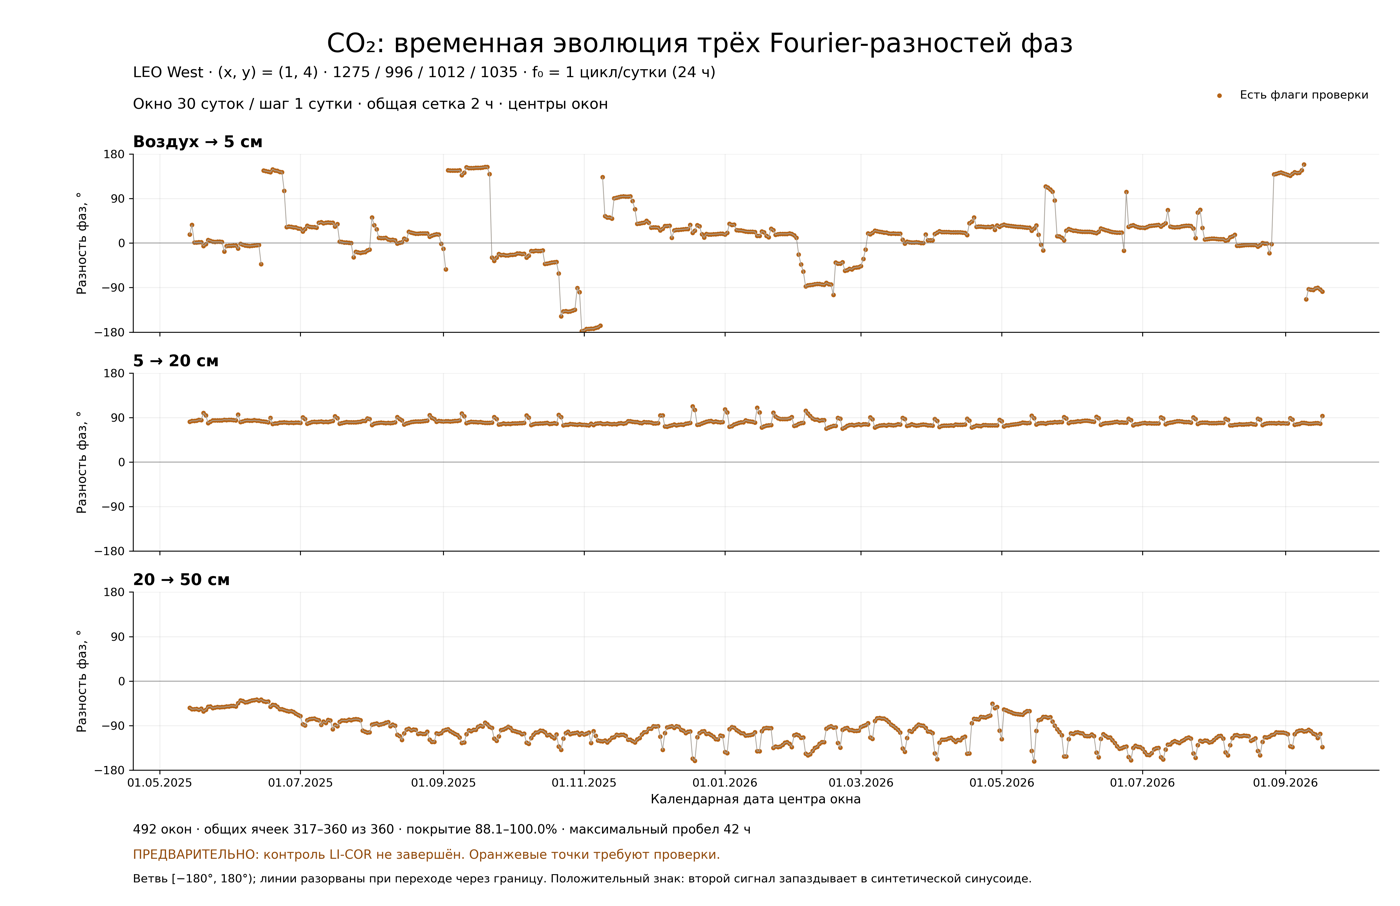

In [3]:
show_image('phase_evolution_17x11.png')

## 8. Предварительная 3D-траектория

$$\left(\Delta\phi_{\mathrm{air}\to5},\Delta\phi_{5\to20},\Delta\phi_{20\to50}\right)\in\mathbb{T}^3=S^1\times S^1\times S^1.$$

Физическое пространство фаз — тор $\mathbb{T}^3$, а куб $[-\pi,\pi)^3$ — его координатное представление со склеенными противоположными гранями. Показаны точки с градиентом календарного времени; соединяющих отрезков нет. Обычное расстояние в кубе не следует трактовать как расстояние на торе.

[Интерактивные 3D-точки в едином HTML](output/preliminary_fourier_phases/phase_evolution.html#trajectory-section). Оси: воздух → 5 см, 5 → 20 см, 20 → 50 см; все в радианах, с отметками $-\pi$, $-\pi/2$, $0$, $\pi/2$, $\pi$. Используются сохранённые значения фаз в радианах; в HTML выполняется только конверсия $\phi_{\rm rad}=\phi_{\rm deg}\pi/180$. Временные ряды остаются в градусах. Статическая картинка ниже сохраняет результат для чтения на GitHub.

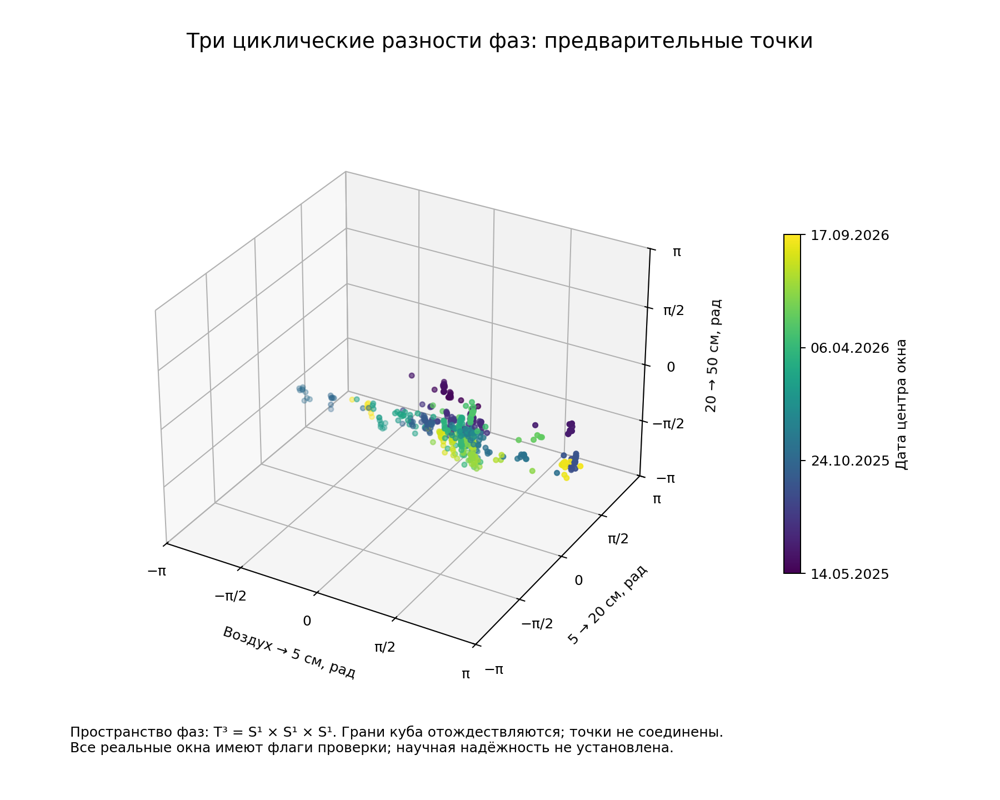

In [4]:
show_image('phase_trajectory_3d.png', 1000)

## 9. Результат, ограничения и воспроизведение

Получена воспроизводимая **предварительная временная демонстрация** трёх Fourier-разностей фаз на принятой частоте: **492 окна**, три фазы вычислены во всех, **492 окна с флагами**, научная надёжность не установлена. Нулевой счёт научно подтверждённых окон здесь означает отсутствие подтверждения этой процедурой, а не доказанную непригодность каждого окна.

Ограничения: незавершённый контроль LI-COR и подземные review-флаги; возможное смещение прямого Fourier-коэффициента пропусками и влиянием иных составляющих; неустойчивость фазы при малом модуле; зависимость перекрывающихся окон. Это не окончательное закрытие допуска 0.2. Частота, размер окна и шаг остаются предварительными.

[Фазы и комплексные коэффициенты](output/preliminary_fourier_phases/phase_timeseries.csv) · [Покрытие каждого окна](output/preliminary_fourier_phases/window_coverage.csv) · [Общие ячейки, средние, числа и флаги](output/preliminary_fourier_phases/common_2h_bins.csv) · [Входы и SHA-256](output/preliminary_fourier_phases/passport.json) · [Проверки](output/preliminary_fourier_phases/validation.json).

В чистом Python-окружении нужны `numpy`, `pandas`, `pyarrow`, `matplotlib`, `Pillow`, `plotly`, `pypdf`; для notebook — `nbformat`, `nbclient`, `ipykernel`. Для автоматической сверки браузерного вычислителя нужен Node.js. Использован снимок `20261002T061358Z-264980`; он должен присутствовать по указанному в техническом паспорте пути. Идентификатор исходного коммита и контрольные суммы входов сохранены в паспорте и validation metadata. Из корня репозитория:

```bash
python -m unittest discover -s Project_description/sensorDB/tests -p test_preliminary_fourier_phases.py -v
python Project_description/sensorDB/preliminary_fourier_phases.py
```

Изменение параметров через Python: `--window-days 60 --step-days 7 --output /tmp/co2-phases-example`. По умолчанию воспроизводится 30/1. Выполнение этого notebook из чистого ядра заново создаёт результаты 30/1 и запускает тесты; исходные данные только читаются, их контрольные суммы сверяются до и после.

Следующий шаг — предъявление результата и нерешённых ограничений I.G. по этапу 0.5 после моего решения. В рамках текущего задания дальнейшее исследование не выполняется.

[Назад: методика и данные](details/02_data_checks.md#preliminary-fourier-phases) · [Принятый план](PLAN.md#preparation).

In [5]:
assert validation['input_hashes_unchanged']
assert validation['pdf_inches'] == [17, 11]
assert validation['png_pixels'] == [5100, 3300]
assert len(phase_table) == 492
assert validation['windows_with_review_flags'] == 492
display(Markdown('**Этап 0.4: предварительный результат получен. Исходные данные и маски сохранены.**'))


**Этап 0.4: предварительный результат получен. Исходные данные и маски сохранены.**